In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

## Step 2: Load Dataset

In [10]:
import zipfile

zip_file = "/content/project 1 data.zip"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("/content/data")

In [11]:
df = pd.read_csv("/content/data/Unemployment in India.csv")

## Step 3: View Dataset

In [12]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [14]:
df.shape

(768, 7)

## Step 4: Clean Column Names

In [15]:
df.columns = df.columns.str.strip()

df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

## Step 5: Check Missing Values

In [16]:
df.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


## Step 6: Remove Missing Values

In [17]:
df = df.dropna()

df.isnull().sum()

,0
Region,0
Date,0
Frequency,0
Estimated Unemployment Rate (%),0
Estimated Employed,0
Estimated Labour Participation Rate (%),0
Area,0


## Step 7: Convert Date Column

In [18]:
df['Date'] = pd.to_datetime(df['Date'])

/tmp/ipykernel_1151/2394721818.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


In [19]:
df.dtypes

,0
Region,object
Date,datetime64[ns]
Frequency,object
Estimated Unemployment Rate (%),float64
Estimated Employed,float64
Estimated Labour Participation Rate (%),float64
Area,object


## Step 8: Basic Statistics

In [20]:
df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


## Step 9: Average Unemployment Rate

In [21]:
avg_rate = df['Estimated Unemployment Rate (%)'].mean()

print("Average Unemployment Rate =", round(avg_rate,2))

Average Unemployment Rate = 11.79


 ## Step 10: Unemployment Rate by State

In [22]:
state_unemployment = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean()

state_unemployment.sort_values(ascending=False).head(10)

,Estimated Unemployment Rate (%)
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


## Step 11: Top 10 States with Highest Unemployment

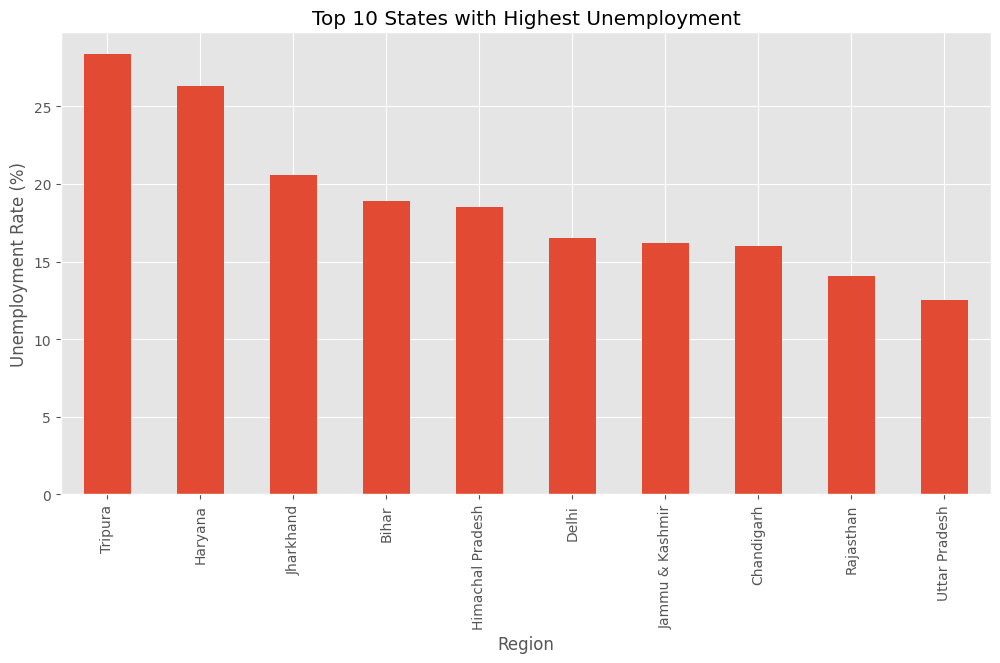

In [23]:
plt.figure(figsize=(12,6))

state_unemployment.sort_values(ascending=False).head(10).plot(kind='bar')

plt.title("Top 10 States with Highest Unemployment")
plt.ylabel("Unemployment Rate (%)")
plt.show()

## Step 12: Overall Unemployment Trend

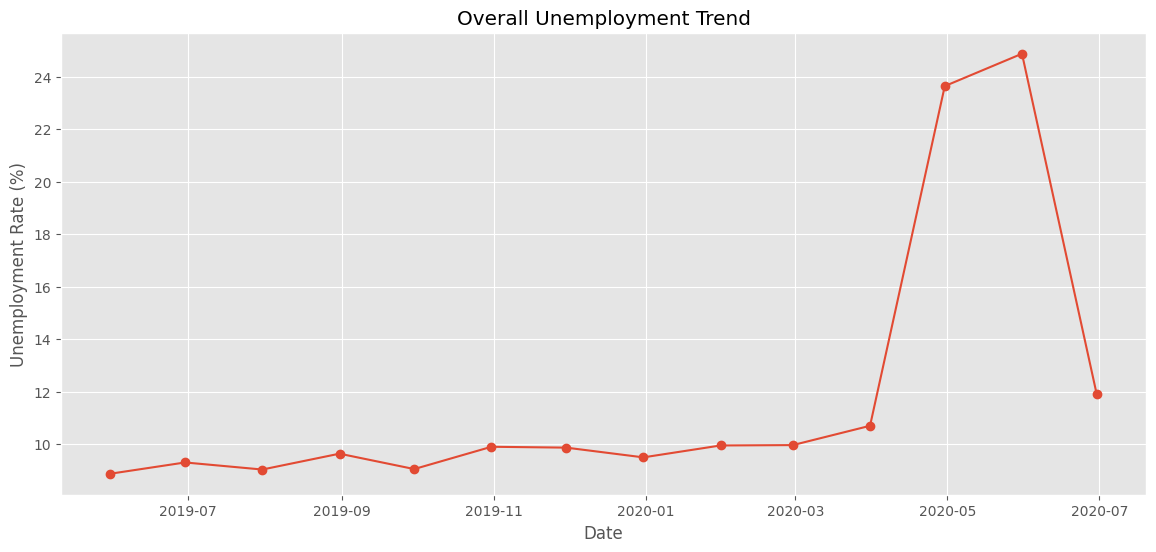

In [24]:
monthly = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(14,6))

plt.plot(monthly.index,
         monthly.values,
         marker='o')

plt.title("Overall Unemployment Trend")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.show()

## Step 13: Covid-19 Impact Analysis

In [25]:
covid_data = df[df['Date'] >= '2020-01-01']

In [26]:
covid_trend = covid_data.groupby('Date')['Estimated Unemployment Rate (%)'].mean()

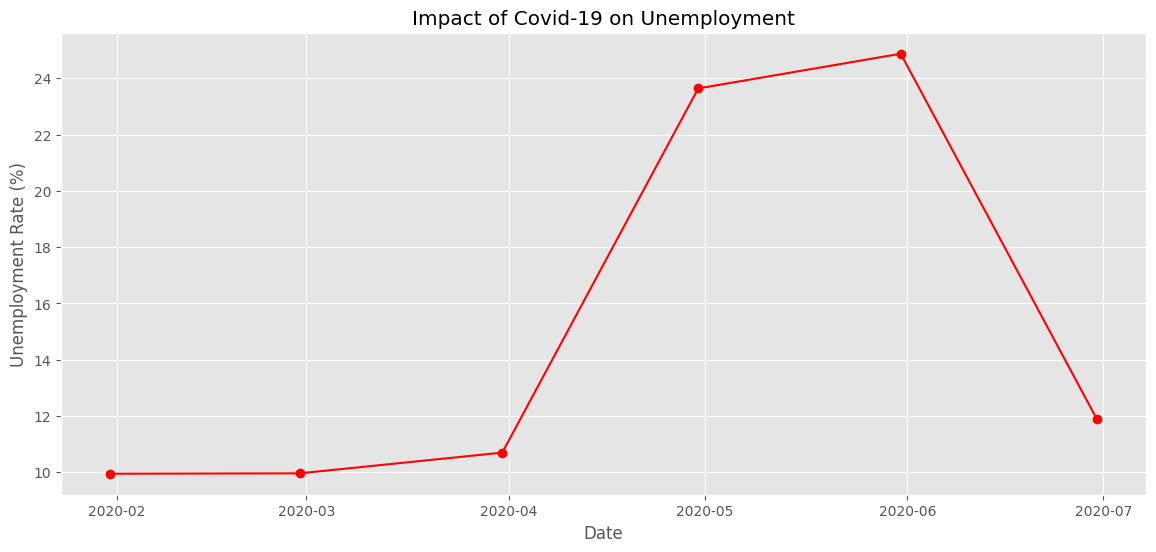

In [27]:
plt.figure(figsize=(14,6))

plt.plot(covid_trend.index,
         covid_trend.values,
         color='red',
         marker='o')

plt.title("Impact of Covid-19 on Unemployment")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.show()

## Step 14: Compare Before and During Covid

In [28]:
df['Period'] = np.where(
    df['Date'] < '2020-03-01',
    'Before Covid',
    'During Covid'
)

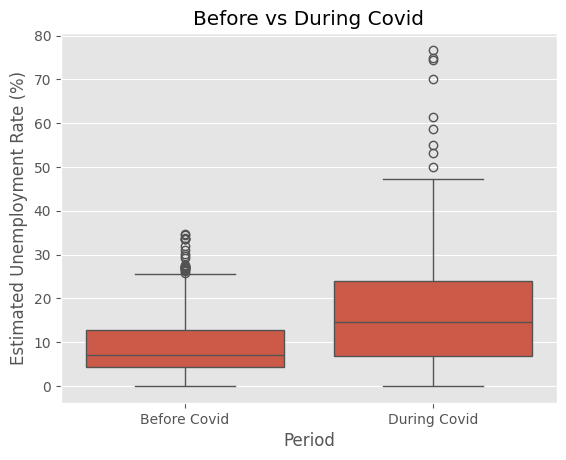

In [29]:
sns.boxplot(
    x='Period',
    y='Estimated Unemployment Rate (%)',
    data=df
)

plt.title("Before vs During Covid")
plt.show()

## Step 15: Area Wise Analysis (Urban vs Rural)

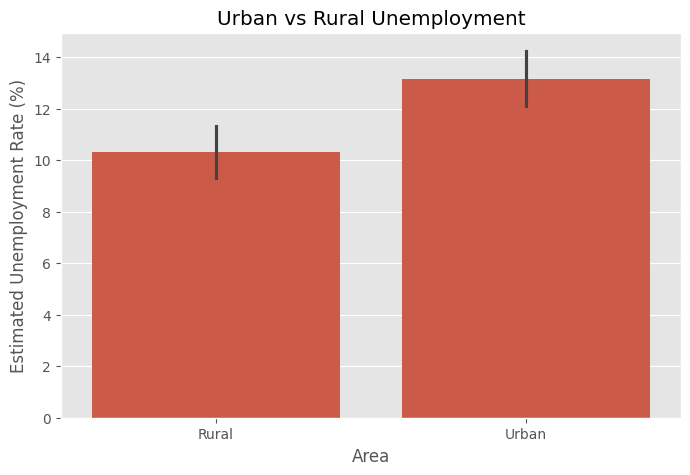

In [30]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Area',
    y='Estimated Unemployment Rate (%)',
    data=df
)

plt.title("Urban vs Rural Unemployment")
plt.show()

## Step 16: Monthly Trend Analysis

In [31]:
df['Month'] = df['Date'].dt.month

In [32]:
monthly_avg = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

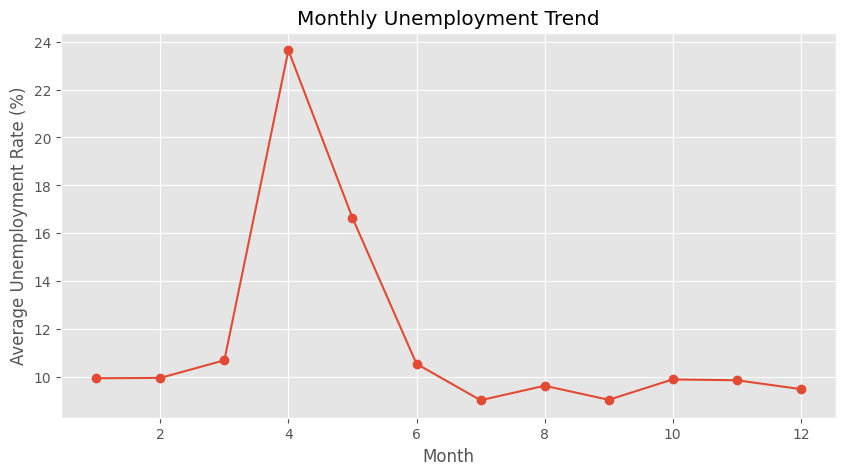

In [33]:
plt.figure(figsize=(10,5))

monthly_avg.plot(marker='o')

plt.title("Monthly Unemployment Trend")
plt.ylabel("Average Unemployment Rate (%)")

plt.show()

## Step 17: Correlation Heatmap

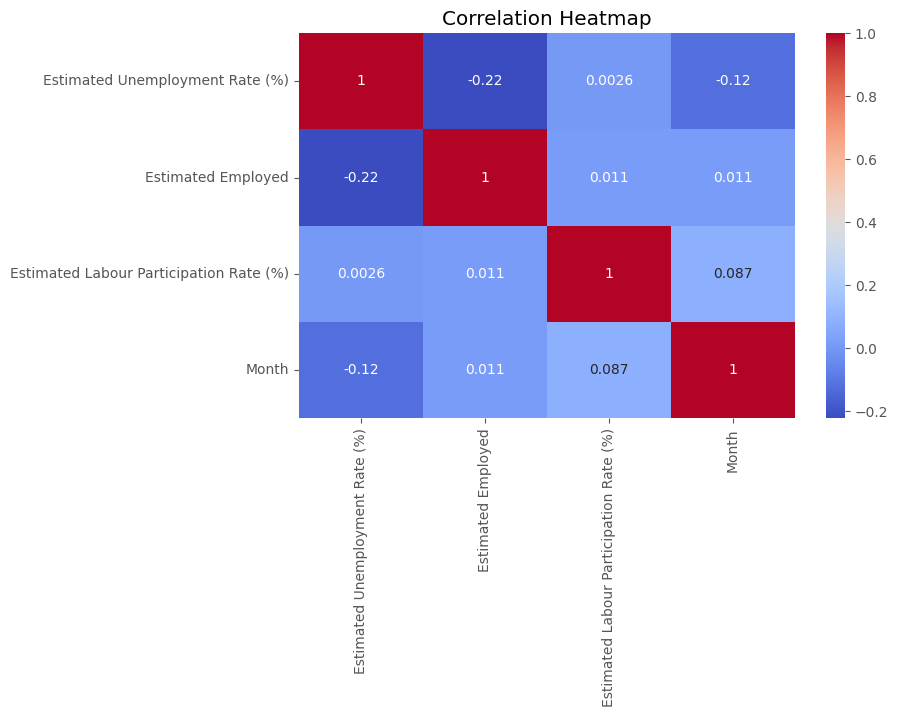

In [34]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

## Step 18: State-wise Heatmap

In [35]:
pivot = df.pivot_table(
    values='Estimated Unemployment Rate (%)',
    index='Region',
    columns='Area'
)

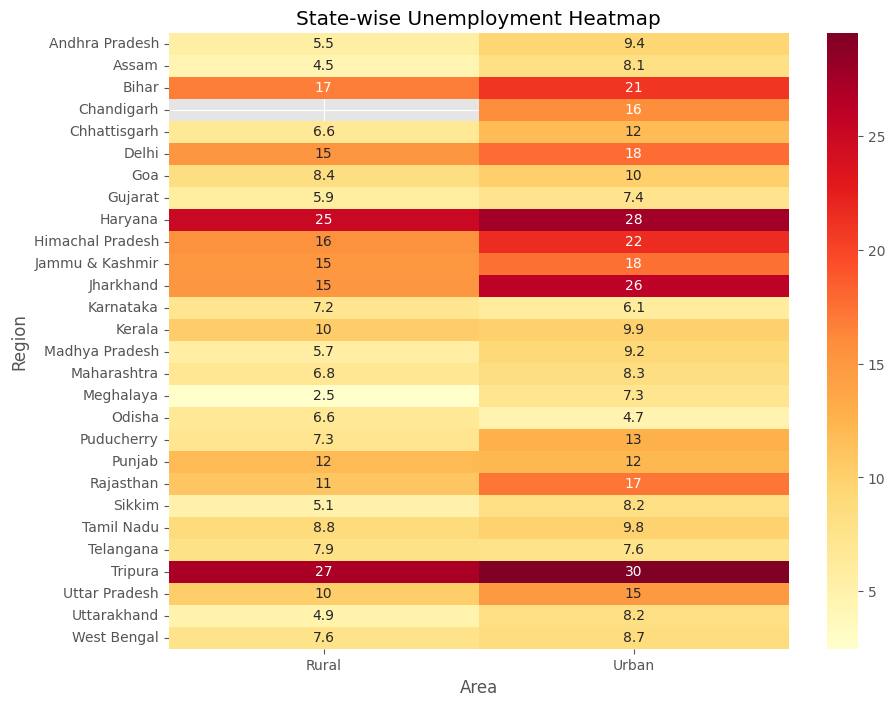

In [36]:
plt.figure(figsize=(10,8))

sns.heatmap(
    pivot,
    annot=True,
    cmap='YlOrRd'
)

plt.title("State-wise Unemployment Heatmap")

plt.show()

## Option 1: Countplot (Recommended)

/tmp/ipykernel_1151/522732526.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


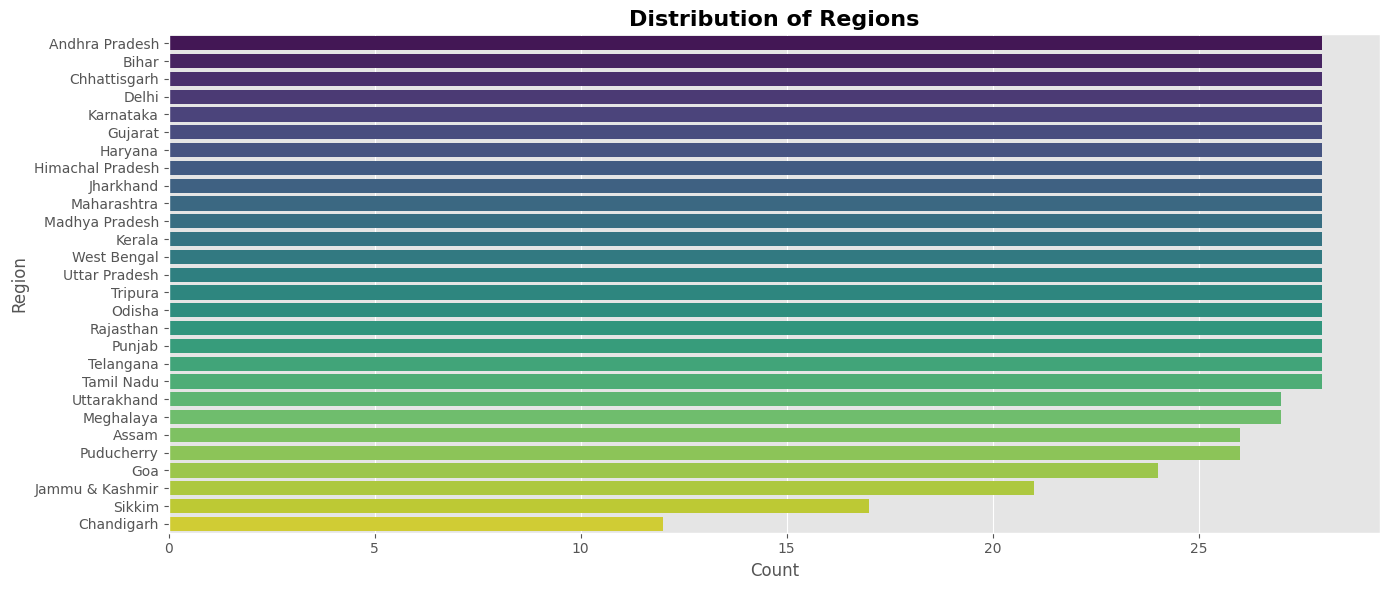

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))

sns.countplot(
    y='Region',
    data=df,
    order=df['Region'].value_counts().index,
    palette='viridis'
)

plt.title('Distribution of Regions', fontsize=16, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Region')
plt.tight_layout()

plt.show()

## Option 2: Pie Chart

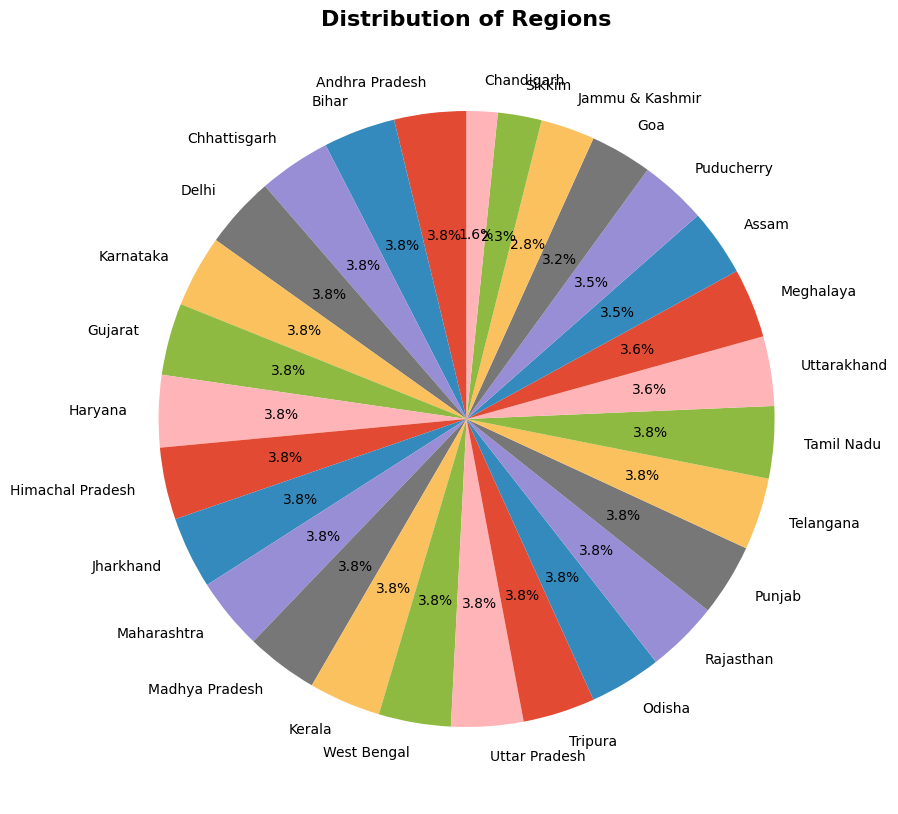

In [39]:
region_counts = df['Region'].value_counts()

plt.figure(figsize=(10,10))

plt.pie(
    region_counts,
    labels=region_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribution of Regions', fontsize=16, fontweight='bold')

plt.show()

## Option 3: Professional Bar Chart

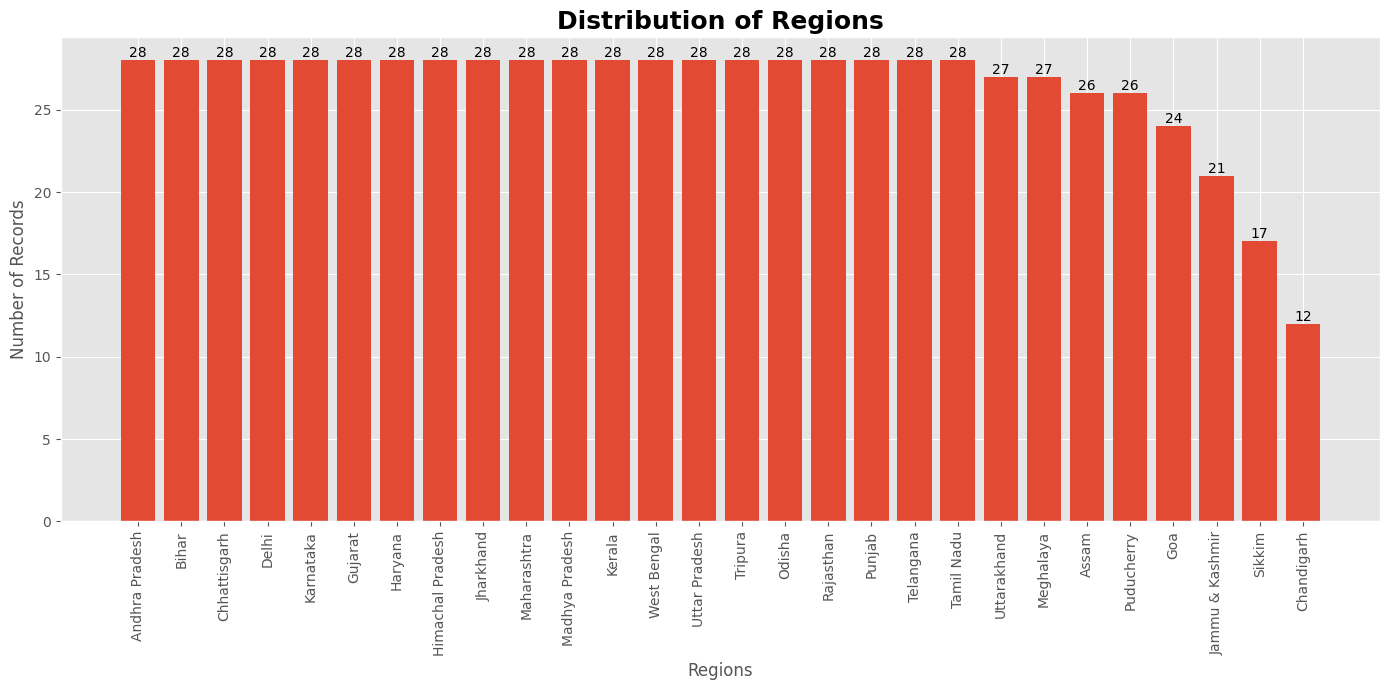

In [40]:
plt.figure(figsize=(14,7))

region_counts = df['Region'].value_counts()

bars = plt.bar(
    region_counts.index,
    region_counts.values
)

plt.xticks(rotation=90)
plt.title('Distribution of Regions', fontsize=18, fontweight='bold')
plt.xlabel('Regions')
plt.ylabel('Number of Records')

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        str(int(bar.get_height())),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

## Labor Force Mystery

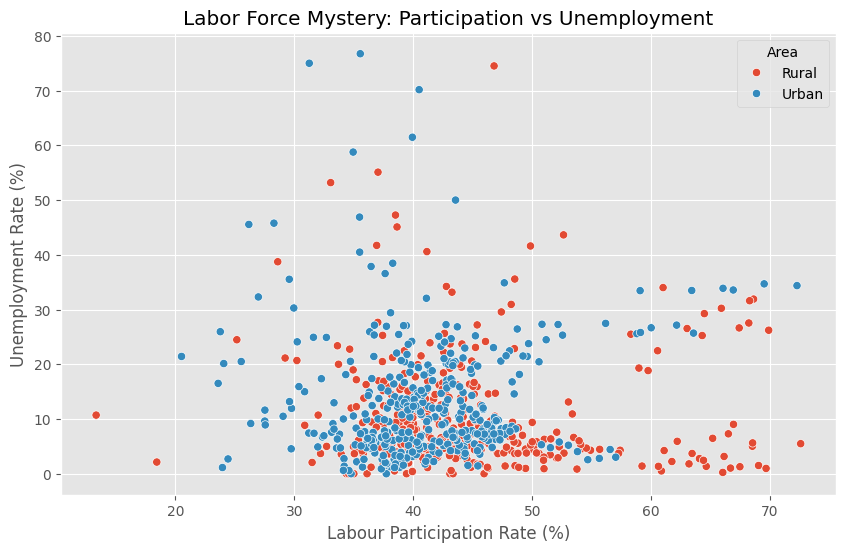

In [41]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Estimated Labour Participation Rate (%)',
    y='Estimated Unemployment Rate (%)',
    hue='Area'
)

plt.title('Labor Force Mystery: Participation vs Unemployment')
plt.xlabel('Labour Participation Rate (%)')
plt.ylabel('Unemployment Rate (%)')

plt.show()

## Heatmap by Region & Month

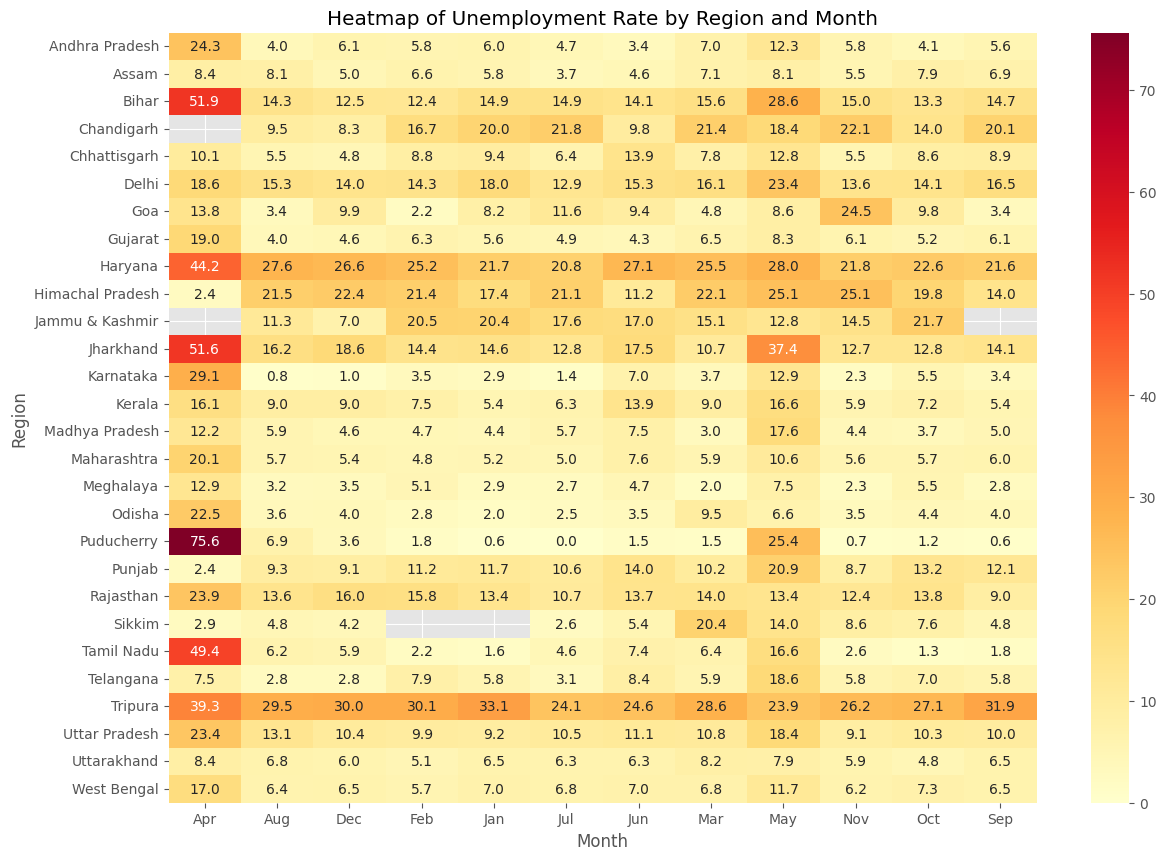

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract month name
df['Month'] = df['Date'].dt.strftime('%b')

# Create pivot table
heatmap_data = df.pivot_table(
    values='Estimated Unemployment Rate (%)',
    index='Region',
    columns='Month',
    aggfunc='mean'
)

# Plot heatmap
plt.figure(figsize=(14,10))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd'
)

plt.title('Heatmap of Unemployment Rate by Region and Month')
plt.xlabel('Month')
plt.ylabel('Region')

plt.show()

## Analysis by States

 ## How states were affected in Year 2020 and 2019?

In [45]:
# Extract Year
df['Year'] = df['Date'].dt.year

# Filter only 2019 and 2020
state_year = df[df['Year'].isin([2019, 2020])]

# Create Pivot Table
comparison = state_year.pivot_table(
    values='Estimated Unemployment Rate (%)',
    index='Region',
    columns='Year',
    aggfunc='mean'
)

# Difference between 2020 and 2019
comparison['Increase'] = comparison[2020] - comparison[2019]

# Sort by increase
comparison = comparison.sort_values('Increase', ascending=False)

print(comparison.head(10))

Year                 2019       2020   Increase
Region                                         
Puducherry       1.699375  23.840000  22.140625
Jharkhand       14.233750  29.053333  14.819583
Tamil Nadu       3.063750  17.578333  14.514583
Bihar           13.882500  25.632500  11.750000
Telangana        4.115625  12.567500   8.451875
Haryana         22.798750  30.929167   8.130417
Karnataka        3.238750  11.259167   8.020417
Kerala           7.131250  14.114167   6.982917
Delhi           13.750625  20.155000   6.404375
Andhra Pradesh   4.826875  11.010833   6.183958
